In [ ]:
import os
import json
import numpy as np
import librosa
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, GlobalAveragePooling2D,
    Dense, Dropout, BatchNormalization
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical



In [2]:
# Bật Memory Growth để tránh OOM
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"GPU sẵn sàng: {len(gpus)} thiết bị")
else:
    print("Không có GPU, dùng CPU")

GPU sẵn sàng: 1 thiết bị


In [3]:
# ============================================================
#  PREPROCESSING CONFIG – Dùng chung cho train VÀ inference
# ============================================================
DATA_DIR      = "../Data/genres_original"
CLASSES       = ['blues', 'classical', 'country', 'disco', 'hiphop',
                 'jazz', 'metal', 'pop', 'reggae', 'rock']
NUM_CLASSES   = len(CLASSES)

CHUNK_DURATION   = 4          # giây
OVERLAP_DURATION = 2          # giây
N_MELS           = 128
TARGET_COLS      = 173        # số cột mel cố định (truncate/pad)
TARGET_SHAPE     = (N_MELS, TARGET_COLS, 1)  # shape đầu vào model

TEST_SIZE   = 0.2
RANDOM_SEED = 42

MODEL_PATH   = "third_genre_classification_model.h5"
HISTORY_PATH = "third_training_history.json"
CONFIG_PATH  = "preprocessing_config.json"

# Lưu config ra file để inference dùng lại
config = {
    "classes":          CLASSES,
    "chunk_duration":   CHUNK_DURATION,
    "overlap_duration": OVERLAP_DURATION,
    "n_mels":           N_MELS,
    "target_cols":      TARGET_COLS,
}
with open(CONFIG_PATH, "w") as f:
    json.dump(config, f, indent=2)

print("Config đã lưu:", CONFIG_PATH)
print(json.dumps(config, indent=2, ensure_ascii=False))

Config đã lưu: preprocessing_config.json
{
  "classes": [
    "blues",
    "classical",
    "country",
    "disco",
    "hiphop",
    "jazz",
    "metal",
    "pop",
    "reggae",
    "rock"
  ],
  "chunk_duration": 4,
  "overlap_duration": 2,
  "n_mels": 128,
  "target_cols": 173
}


In [5]:
def audio_to_mel_chunks(file_path,
                         chunk_duration=CHUNK_DURATION,
                         overlap_duration=OVERLAP_DURATION,
                         n_mels=N_MELS,
                         target_cols=TARGET_COLS):
    """
    Đọc file âm thanh và trả về danh sách mel spectrogram chunks.
    Dùng TRUNCATE/PAD để cố định kích thước – KHÔNG dùng resize.

    Returns:
        list of np.ndarray, mỗi array shape (n_mels, target_cols, 1)
        Trả về list rỗng nếu file lỗi.
    """
    try:
        audio, sr = librosa.load(file_path, sr=22050)
    except Exception as e:
        print(f"  [Cảnh báo] Bỏ qua file lỗi: {os.path.basename(file_path)} ({e})")
        return []

    chunk_samples   = chunk_duration   * sr
    overlap_samples = overlap_duration * sr
    step            = chunk_samples - overlap_samples

    if len(audio) < chunk_samples:
        # File quá ngắn, không đủ 1 chunk
        return []

    num_chunks = int(np.ceil((len(audio) - chunk_samples) / step)) + 1
    chunks_out = []

    for i in range(num_chunks):
        start = int(i * step)
        end   = start + int(chunk_samples)
        chunk = audio[start:end]

        if len(chunk) < chunk_samples:
            continue  # Bỏ chunk cuối nếu quá ngắn

        # --- Tính mel spectrogram ---
        mel = librosa.feature.melspectrogram(y=chunk, sr=sr, n_mels=n_mels)
        mel_db = librosa.power_to_db(mel, ref=np.max)

        # --- Normalize [0, 1] với epsilon để tránh chia cho 0 ---
        mel_min, mel_max = mel_db.min(), mel_db.max()
        mel_norm = (mel_db - mel_min) / (mel_max - mel_min + 1e-6)

        # --- Truncate / Pad theo trục thời gian (cột) – KHÔNG resize ---
        current_cols = mel_norm.shape[1]
        if current_cols >= target_cols:
            mel_fixed = mel_norm[:, :target_cols]
        else:
            pad = target_cols - current_cols
            mel_fixed = np.pad(mel_norm, ((0, 0), (0, pad)), mode='constant', constant_values=0)

        # Thêm chiều channel → (n_mels, target_cols, 1)
        chunks_out.append(np.expand_dims(mel_fixed, axis=-1))

    return chunks_out

print("Hàm audio_to_mel_chunks đã sẵn sàng.")

Hàm audio_to_mel_chunks đã sẵn sàng.


In [5]:
def get_file_split(data_dir, classes, test_size=TEST_SIZE, random_state=RANDOM_SEED):
    """
    Chia danh sách FILE (không phải chunk) thành train/test.
    Đảm bảo không có data leakage giữa hai tập.
    """
    train_files, test_files = [], []
    train_labels, test_labels = [], []

    for label_idx, class_name in enumerate(classes):
        class_dir = os.path.join(data_dir, class_name)
        files = sorted([
            os.path.join(class_dir, f)
            for f in os.listdir(class_dir)
            if f.endswith('.wav')
        ])

        labels = [label_idx] * len(files)
        Xtr, Xte, ytr, yte = train_test_split(
            files, labels,
            test_size=test_size,
            random_state=random_state
        )
        train_files.extend(Xtr); train_labels.extend(ytr)
        test_files.extend(Xte);  test_labels.extend(yte)

    print(f"File train: {len(train_files)} | File test: {len(test_files)}")
    return train_files, test_files, train_labels, test_labels


train_files, test_files, train_labels_raw, test_labels_raw = get_file_split(
    DATA_DIR, CLASSES
)

File train: 800 | File test: 200


In [6]:
def build_dataset(file_list, label_list, split_name=""):
    """
    Với mỗi file trong danh sách, tạo chunks và gắn nhãn.
    """
    X_list, y_list = [], []
    total = len(file_list)

    for i, (fp, label) in enumerate(zip(file_list, label_list)):
        if (i + 1) % 50 == 0 or (i + 1) == total:
            print(f"  [{split_name}] {i+1}/{total} files...")

        chunks = audio_to_mel_chunks(fp)
        for chunk in chunks:
            X_list.append(chunk)
            y_list.append(label)

    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.int32)
    print(f"  [{split_name}] Tổng chunks: {X.shape[0]}, shape: {X.shape}")
    return X, y


print("Đang xử lý tập Train...")
X_train, y_train_raw = build_dataset(train_files, train_labels_raw, "Train")

print("\nĐang xử lý tập Test...")
X_test, y_test_raw = build_dataset(test_files, test_labels_raw, "Test")

Đang xử lý tập Train...
  [Train] 50/800 files...
  [Train] 100/800 files...
  [Train] 150/800 files...
  [Train] 200/800 files...
  [Train] 250/800 files...
  [Train] 300/800 files...
  [Train] 350/800 files...
  [Train] 400/800 files...


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_3080\1202653009.py:15: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(file_path, sr=22050)
d:\CondaEnvs\tensorflow_env\lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


  [Cảnh báo] Bỏ qua file lỗi: jazz.00054.wav ()
  [Train] 450/800 files...
  [Train] 500/800 files...
  [Train] 550/800 files...
  [Train] 600/800 files...
  [Train] 650/800 files...
  [Train] 700/800 files...
  [Train] 750/800 files...
  [Train] 800/800 files...
  [Train] Tổng chunks: 11179, shape: (11179, 128, 173, 1)

Đang xử lý tập Test...
  [Test] 50/200 files...
  [Test] 100/200 files...
  [Test] 150/200 files...
  [Test] 200/200 files...
  [Test] Tổng chunks: 2798, shape: (2798, 128, 173, 1)


In [7]:
y_train = to_categorical(y_train_raw, num_classes=NUM_CLASSES)
y_test  = to_categorical(y_test_raw,  num_classes=NUM_CLASSES)

print(f"X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}   y_test:  {y_test.shape}")
print(f"\nPhân phối nhãn train: { {CLASSES[i]: int((y_train_raw == i).sum()) for i in range(NUM_CLASSES)} }")

X_train: (11179, 128, 173, 1)  y_train: (11179, 10)
X_test:  (2798, 128, 173, 1)   y_test:  (2798, 10)

Phân phối nhãn train: {'blues': 1120, 'classical': 1118, 'country': 1118, 'disco': 1119, 'hiphop': 1119, 'jazz': 1106, 'metal': 1120, 'pop': 1120, 'reggae': 1120, 'rock': 1119}


In [ ]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, GlobalAveragePooling2D,
    Dense, Dropout, BatchNormalization, GaussianNoise, Input
)
from tensorflow.keras.regularizers import l2

def build_advanced_model(input_shape=TARGET_SHAPE, num_classes=NUM_CLASSES):
    """
    CNN nâng cao áp dụng cấu trúc VGG-style:
    - Thêm GaussianNoise để Augmentation.
    - Stack 2 lớp Conv2D trong mỗi block để học đặc trưng sâu hơn.
    - Dropout tăng dần để chống overfit tối đa.
    """
    model = Sequential(name="advanced_music_genre_cnn")
    
    # Layer Input tường minh (khuyến nghị trong TF 2.x)
    model.add(Input(shape=input_shape))
    
    # 1. DATA AUGMENTATION (Chỉ hoạt động lúc Train, bị tắt lúc Test/Inference)
    # Thêm nhiễu Gaussian nhẹ giúp model "lì đòn" hơn với các file mp3 có tạp âm
    model.add(GaussianNoise(0.05))

    # --- BLOCK 1 ---
    # Lớp đầu tiên dùng kernel (5, 3): 5 pixel dọc (Tần số) x 3 pixel ngang (Thời gian)
    # Lý do: Trong Spectrogram, việc quét dải tần số rộng hơn ở lớp đầu mang lại nhiều thông tin âm sắc.
    model.add(Conv2D(32, (5, 3), activation='relu', padding='same', kernel_regularizer=l2(0.001)))
    model.add(BatchNormalization())
    
    # Lớp Conv2D thứ hai theo chuẩn VGG
    model.add(Conv2D(32, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(0.001)))
    model.add(BatchNormalization())
    
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.2)) # Dropout nhẹ ở những lớp đầu

    # --- BLOCK 2 ---
    model.add(Conv2D(64, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(0.001)))
    model.add(BatchNormalization())
    model.add(Conv2D(64, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(0.001)))
    model.add(BatchNormalization())
    
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.3))

    # --- BLOCK 3 ---
    model.add(Conv2D(128, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(0.001)))
    model.add(BatchNormalization())
    model.add(Conv2D(128, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(0.001)))
    model.add(BatchNormalization())
    
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.4)) 

    # --- GỘP NHÁNH & PHÂN LOẠI  ---
    model.add(GlobalAveragePooling2D())

    # Classifier Layer
    model.add(Dense(256, activation='relu', kernel_regularizer=l2(0.001)))
    model.add(Dropout(0.5)) # Dropout mạnh nhất ở lớp Dense cuối
    model.add(Dense(num_classes, activation='softmax'))

    return model

# Khởi tạo và in tóm tắt mô hình
model = build_advanced_model()
model.summary()

Model: "advanced_music_genre_cnn"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gaussian_noise (GaussianNoi  (None, 128, 173, 1)      0         
 se)                                                             
                                                                 
 conv2d (Conv2D)             (None, 128, 173, 32)      512       
                                                                 
 batch_normalization (BatchN  (None, 128, 173, 32)     128       
 ormalization)                                                   
                                                                 
 conv2d_1 (Conv2D)           (None, 128, 173, 32)      9248      
                                                                 
 batch_normalization_1 (Batc  (None, 128, 173, 32)     128       
 hNormalization)                                                 
                                          

In [9]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    # Dừng sớm nếu val_loss không giảm sau 10 epoch, khôi phục best weights
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    # Giảm LR x0.5 nếu val_loss đi ngang sau 5 epoch
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),
    # Luôn lưu model tốt nhất (theo val_accuracy)
    ModelCheckpoint(
        filepath=MODEL_PATH,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,        # EarlyStopping sẽ dừng sớm nếu cần
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

print(f"\nModel tốt nhất đã lưu: {MODEL_PATH}")

Epoch 1/100
350/350 [==============================] - ETA: 0s - loss: 1.8116 - accuracy: 0.5159
Epoch 1: val_accuracy improved from -inf to 0.10007, saving model to third_genre_classification_model.h5
350/350 [==============================] - 63s 132ms/step - loss: 1.8116 - accuracy: 0.5159 - val_loss: 12.1954 - val_accuracy: 0.1001 - lr: 0.0010
Epoch 2/100
349/350 [============================>.] - ETA: 0s - loss: 1.2576 - accuracy: 0.6868
Epoch 2: val_accuracy improved from 0.10007 to 0.37205, saving model to third_genre_classification_model.h5
350/350 [==============================] - 40s 115ms/step - loss: 1.2577 - accuracy: 0.6867 - val_loss: 2.5226 - val_accuracy: 0.3721 - lr: 0.0010
Epoch 3/100
349/350 [============================>.] - ETA: 0s - loss: 1.0321 - accuracy: 0.7524
Epoch 3: val_accuracy did not improve from 0.37205
350/350 [==============================] - 40s 114ms/step - loss: 1.0321 - accuracy: 0.7525 - val_loss: 5.5537 - val_accuracy: 0.3131 - lr: 0.0010
Epo

In [10]:
class NumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, (np.floating,)): return float(obj)
        if isinstance(obj, (np.integer,)):  return int(obj)
        if isinstance(obj, np.ndarray):     return obj.tolist()
        return super().default(obj)

with open(HISTORY_PATH, "w") as f:
    json.dump(history.history, f, cls=NumpyEncoder, indent=2)

print(f"Lịch sử training đã lưu: {HISTORY_PATH}")

Lịch sử training đã lưu: third_training_history.json


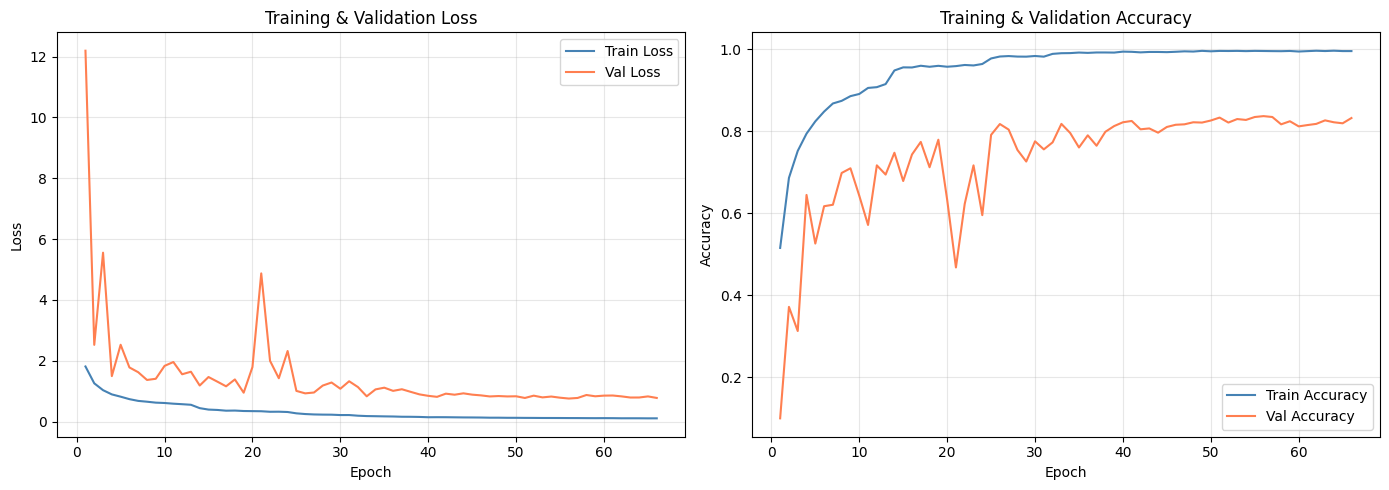

Best val_accuracy: 0.8374


In [11]:
hist = history.history
epochs_ran = range(1, len(hist['loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_ran, hist['loss'],     label='Train Loss',     color='steelblue')
ax1.plot(epochs_ran, hist['val_loss'], label='Val Loss',       color='coral')
ax1.set_title('Training & Validation Loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(epochs_ran, hist['accuracy'],     label='Train Accuracy', color='steelblue')
ax2.plot(epochs_ran, hist['val_accuracy'], label='Val Accuracy',   color='coral')
ax2.set_title('Training & Validation Accuracy')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Best val_accuracy: {max(hist['val_accuracy']):.4f}")

Classification Report:
              precision    recall  f1-score   support

       blues       0.94      0.77      0.84       280
   classical       0.89      0.97      0.93       280
     country       0.77      0.73      0.75       279
       disco       0.84      0.85      0.84       280
      hiphop       0.81      0.77      0.79       279
        jazz       0.88      0.93      0.90       280
       metal       0.93      0.92      0.92       280
         pop       0.76      0.89      0.82       280
      reggae       0.84      0.82      0.83       280
        rock       0.74      0.72      0.73       280

    accuracy                           0.84      2798
   macro avg       0.84      0.84      0.84      2798
weighted avg       0.84      0.84      0.84      2798



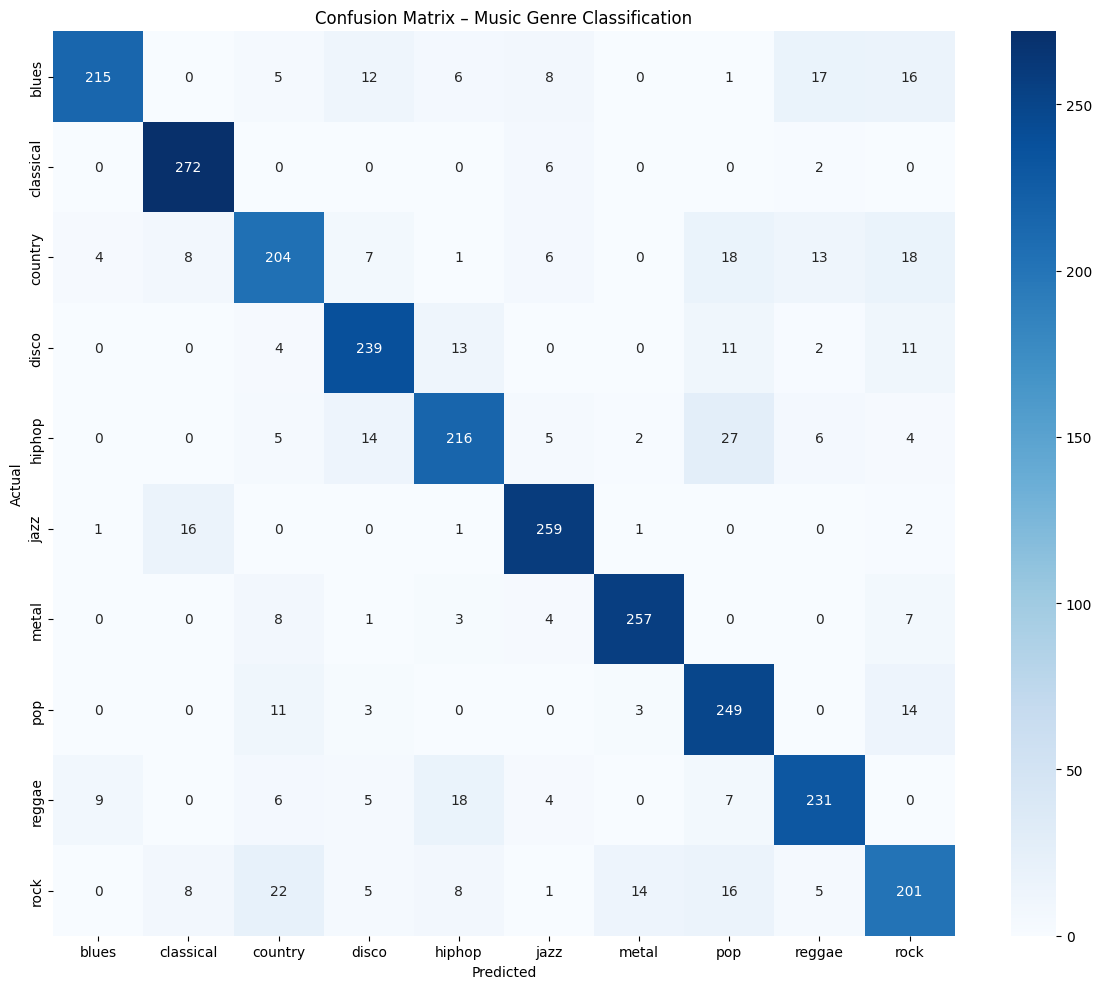

In [12]:
# Load lại best model để đánh giá
best_model = tf.keras.models.load_model(MODEL_PATH)

y_pred_prob = best_model.predict(X_test, batch_size=32, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=CLASSES))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title('Confusion Matrix – Music Genre Classification')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

TEST MÔ HÌNH

In [6]:
def predict_genre(file_path, model, classes=CLASSES, top_k=3):
    """
    Dự đoán thể loại nhạc cho một file âm thanh.

    Pipeline PHẢI khớp với lúc train:
      - Dùng audio_to_mel_chunks() (truncate/pad)
      - KHÔNG dùng tf.image.resize()

    Args:
        file_path: đường dẫn file .wav hoặc .mp3
        model:     model đã load
        classes:   danh sách tên thể loại
        top_k:     số thể loại có xác suất cao nhất để hiển thị

    Returns:
        dict với 'genre' và 'confidence' và 'top_k_predictions'
    """
    # Bước 1: Chạy qua đúng pipeline như lúc train
    chunks = audio_to_mel_chunks(file_path)

    if len(chunks) == 0:
        print("Không có chunk hợp lệ từ file này.")
        return None

    X_input = np.array(chunks, dtype=np.float32)  # (N_chunks, 128, 173, 1)

    # Bước 2: Dự đoán từng chunk
    y_pred_chunks = model.predict(X_input, batch_size=16, verbose=0)  # (N_chunks, 10)

    # Bước 3: Tổng hợp bằng majority vote trên softmax scores trung bình
    avg_scores = y_pred_chunks.mean(axis=0)  # (10,)
    predicted_idx = np.argmax(avg_scores)

    # Top-k predictions
    top_k_idx = np.argsort(avg_scores)[::-1][:top_k]
    top_k_preds = [(classes[i], float(avg_scores[i])) for i in top_k_idx]

    result = {
        "genre":           classes[predicted_idx],
        "confidence":      float(avg_scores[predicted_idx]),
        "num_chunks":      len(chunks),
        "top_k_predictions": top_k_preds,
    }
    return result

print("Hàm predict_genre() sẵn sàng.")

Hàm predict_genre() sẵn sàng.


In [9]:
# Đổi đường dẫn sang file âm thanh muốn test
TEST_FILE = "../Data_Test/jonasblakewood-pop-dance-friends-frequencies-445891.mp3"
# TEST_FILE = "../Data/genres_original/blues/blues.00055.wav"
from IPython.display import Audio
y_audio, sr_audio = librosa.load(TEST_FILE, sr=22050)
print(f"File: {os.path.basename(TEST_FILE)}")
print(f"Duration: {len(y_audio)/sr_audio:.1f}s | Sample rate: {sr_audio} Hz")
Audio(y_audio, rate=sr_audio)

File: jonasblakewood-pop-dance-friends-frequencies-445891.mp3
Duration: 131.9s | Sample rate: 22050 Hz


In [10]:
# Load best model và chạy inference
best_model = tf.keras.models.load_model(MODEL_PATH)

result = predict_genre(TEST_FILE, best_model)

if result:
    print(f"\n{'='*45}")
    print(f"  Kết quả dự đoán")
    print(f"{'='*45}")
    print(f"  Thể loại:    {result['genre'].upper()}")
    print(f"  Confidence:  {result['confidence']:.2%}")
    print(f"  Số chunks:   {result['num_chunks']}")
    print(f"\n  Top-{len(result['top_k_predictions'])} dự đoán:")
    for genre, score in result['top_k_predictions']:
        bar = '█' * int(score * 30)
        print(f"    {genre:<12} {bar:<30} {score:.2%}")
    print(f"{'='*45}")


  Kết quả dự đoán
  Thể loại:    POP
  Confidence:  36.01%
  Số chunks:   64

  Top-3 dự đoán:
    pop          ██████████                     36.01%
    hiphop       ██████████                     35.11%
    disco        ████                           14.64%
